# 🧴 PlastiSort AI — Notebook 2: Detector & Sorting Controller

This notebook covers:
- Writing the YOLO detector module (with mock fallback)
- Writing the GPIO sorting arm controller (with software stub)
- Writing the SQLite database logging module
- Live demo: run the full detection → sort → log pipeline on a synthetic frame

---
> **Prerequisite:** Run Notebook 1 first so the `plastisort/` folder and `preprocessing.py` exist.

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('plastisort')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT.resolve()}')

Project root: C:\Users\aaa\Bottler sorter\plastisort


## 1. Write detector.py

In [16]:
detector_code = '''
import random, logging
import numpy as np
from pathlib import Path

logger = logging.getLogger(__name__)

try:
    from ultralytics import YOLO as _YOLO
    ULTRALYTICS_AVAILABLE = True
except ImportError:
    ULTRALYTICS_AVAILABLE = False

DEFAULT_CONF_THRESHOLD = 0.50
PLASTIC_BOTTLE_CLASS   = "plastic_bottle"


class YOLODetector:
    """Real YOLOv5/v8 detector. Requires models/best.pt after training."""
    def __init__(self, model_path="models/best.pt", conf_threshold=DEFAULT_CONF_THRESHOLD):
        if not ULTRALYTICS_AVAILABLE:
            raise RuntimeError("Install ultralytics: pip install ultralytics")
        if not Path(model_path).exists():
            raise FileNotFoundError(f"Weights not found: {model_path}. Train first (Notebook 3).")
        self.conf_threshold = conf_threshold
        self._model = _YOLO(model_path)
        self._model.conf = conf_threshold
        logger.info("YOLODetector loaded: %s", model_path)

    def detect(self, frame):
        results = self._model(frame, verbose=False)
        detections = []
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                label  = self._model.names.get(cls_id, "unknown")
                conf   = float(box.conf[0])
                x1,y1,x2,y2 = box.xyxy[0].tolist()
                detections.append({"x1":x1,"y1":y1,"x2":x2,"y2":y2,
                                    "confidence":conf,"label":label,"class_id":cls_id})
        return detections

    def draw_boxes(self, frame, detections):
        from preprocessing import draw_bounding_boxes
        return draw_bounding_boxes(frame, detections)


class MockDetector:
    """Simulated detector - generates random detections. No model needed."""
    def __init__(self, conf_threshold=DEFAULT_CONF_THRESHOLD, detection_rate=0.4):
        self.conf_threshold = conf_threshold
        self.detection_rate = detection_rate
        logger.info("MockDetector ready (detection_rate=%.1f)", detection_rate)

    def detect(self, frame):
        if random.random() > self.detection_rate:
            return []
        h, w = frame.shape[:2] if hasattr(frame, "shape") else (416, 416)
        detections = []
        for _ in range(random.randint(1, 2)):
            x1 = random.randint(10, w//2)
            y1 = random.randint(10, h//2)
            x2 = random.randint(x1+40, min(x1+200, w-10))
            y2 = random.randint(y1+80, min(y1+280, h-10))
            conf = round(random.uniform(self.conf_threshold, 1.0), 3)
            detections.append({"x1":x1,"y1":y1,"x2":x2,"y2":y2,
                                "confidence":conf,"label":PLASTIC_BOTTLE_CLASS,"class_id":0})
        return detections

    def draw_boxes(self, frame, detections):
        from preprocessing import draw_bounding_boxes
        return draw_bounding_boxes(frame, detections)


def get_detector(model_path="models/best.pt", conf_threshold=DEFAULT_CONF_THRESHOLD):
    """Return YOLODetector if weights exist, otherwise MockDetector."""
    if Path(model_path).exists() and ULTRALYTICS_AVAILABLE:
        try:
            return YOLODetector(model_path, conf_threshold)
        except Exception as e:
            logger.warning("Falling back to MockDetector: %s", e)
    logger.info("MockDetector active (no weights at %s)", model_path)
    return MockDetector(conf_threshold)
'''

with open(PROJECT_ROOT / 'src' / 'detector.py', 'w') as f:
    f.write(detector_code)
print('✅ detector.py written')

✅ detector.py written


## 2. Write controller.py

In [15]:
controller_code = '''
import time, logging, threading
from typing import Callable, Optional

logger = logging.getLogger(__name__)

SERVO_PIN          = 18
PWM_FREQUENCY      = 50
DUTY_ACTIVATE      = 7.5
DUTY_NEUTRAL       = 2.5
ARM_ACTIVE_SECONDS = 0.5
ARM_RETURN_DELAY   = 0.2

try:
    import RPi.GPIO as _GPIO
    _GPIO_AVAILABLE = True
except (ImportError, RuntimeError):
    _GPIO_AVAILABLE = False


class GPIOController:
    """Real Raspberry Pi GPIO servo controller."""
    def __init__(self, pin=SERVO_PIN, on_sort=None):
        self.pin, self.on_sort = pin, on_sort
        self._lock = threading.Lock()
        _GPIO.setmode(_GPIO.BCM)
        _GPIO.setup(pin, _GPIO.OUT)
        self._pwm = _GPIO.PWM(pin, PWM_FREQUENCY)
        self._pwm.start(0)
    def activate_sorting_arm(self, duration=ARM_ACTIVE_SECONDS):
        with self._lock:
            self._pwm.ChangeDutyCycle(DUTY_ACTIVATE)
            time.sleep(duration)
            self._pwm.ChangeDutyCycle(DUTY_NEUTRAL)
            time.sleep(ARM_RETURN_DELAY)
            self._pwm.ChangeDutyCycle(0)
        if self.on_sort: self.on_sort()
    def cleanup(self):
        self._pwm.stop(); _GPIO.cleanup()


class StubController:
    """Software stub - logs instead of moving hardware."""
    def __init__(self, pin=SERVO_PIN, on_sort=None):
        self.pin, self.on_sort = pin, on_sort
        self._lock = threading.Lock()
        self.sort_count = 0
        logger.info("StubController ready on pin %d (no GPIO)", pin)
    def activate_sorting_arm(self, duration=ARM_ACTIVE_SECONDS):
        with self._lock:
            self.sort_count += 1
            logger.info("[STUB] Arm activated - bottle #%d diverted", self.sort_count)
            time.sleep(duration + ARM_RETURN_DELAY)
        if self.on_sort: self.on_sort()
    def cleanup(self):
        logger.info("[STUB] Cleaned up. Total sorts: %d", self.sort_count)


class SortingController:
    """Thread-safe non-blocking wrapper. Uses GPIO on Pi, Stub otherwise."""
    def __init__(self, pin=SERVO_PIN, on_sort=None):
        self._hw   = GPIOController(pin, on_sort) if _GPIO_AVAILABLE else StubController(pin, on_sort)
        self._busy = False
    @property
    def is_real_hardware(self):
        return isinstance(self._hw, GPIOController)
    def trigger(self, duration=ARM_ACTIVE_SECONDS):
        if self._busy: return
        def _run():
            self._busy = True
            try:    self._hw.activate_sorting_arm(duration)
            finally: self._busy = False
        threading.Thread(target=_run, daemon=True).start()
    def cleanup(self):
        self._hw.cleanup()
'''

with open(PROJECT_ROOT / 'src' / 'controller.py', 'w') as f:
    f.write(controller_code)
print('✅ controller.py written')

✅ controller.py written


## 3. Write database.py

In [13]:
# -*- coding: utf-8 -*-
database_code = '''
import datetime
from sqlalchemy import create_engine, Column, Integer, Float, String, DateTime, ForeignKey
from sqlalchemy.orm import declarative_base, sessionmaker, relationship

Base = declarative_base()

class Camera(Base):
    __tablename__ = "cameras"
    camera_id         = Column(Integer, primary_key=True, autoincrement=True)
    location          = Column(String(100), default="Conveyor Belt")
    resolution        = Column(String(20),  default="640x480")
    status            = Column(String(20),  default="active")
    installation_date = Column(DateTime, default=datetime.datetime.utcnow)
    events = relationship("DetectionEvent", back_populates="camera", cascade="all, delete-orphan")
    def to_dict(self):
        return {"camera_id":self.camera_id,"location":self.location,"resolution":self.resolution,
                "status":self.status,"installation_date":self.installation_date.isoformat() if self.installation_date else None}

class DetectionEvent(Base):
    __tablename__ = "detection_events"
    event_id         = Column(Integer, primary_key=True, autoincrement=True)
    camera_id        = Column(Integer, ForeignKey("cameras.camera_id"), nullable=True)
    frame_number     = Column(Integer, default=0)
    timestamp        = Column(DateTime, default=datetime.datetime.utcnow, index=True)
    class_label      = Column(String(50),  default="plastic_bottle")
    confidence_score = Column(Float)
    bbox_x = Column(Integer); bbox_y = Column(Integer)
    bbox_width = Column(Integer); bbox_height = Column(Integer)
    camera = relationship("Camera", back_populates="events")
    action = relationship("SortingAction", back_populates="event", uselist=False, cascade="all, delete-orphan")
    def to_dict(self):
        return {"event_id":self.event_id,"camera_id":self.camera_id,"frame_number":self.frame_number,
                "timestamp":self.timestamp.isoformat() if self.timestamp else None,
                "class_label":self.class_label,"confidence_score":round(self.confidence_score,4),
                "bbox_x":self.bbox_x,"bbox_y":self.bbox_y,"bbox_width":self.bbox_width,"bbox_height":self.bbox_height}

class SortingAction(Base):
    __tablename__ = "sorting_actions"
    action_id        = Column(Integer, primary_key=True, autoincrement=True)
    event_id         = Column(Integer, ForeignKey("detection_events.event_id"))
    action_timestamp = Column(DateTime, default=datetime.datetime.utcnow)
    outcome          = Column(String(50), default="diverted")
    response_time_ms = Column(Float)
    event = relationship("DetectionEvent", back_populates="action")
    def to_dict(self):
        return {"action_id":self.action_id,"event_id":self.event_id,
                "action_timestamp":self.action_timestamp.isoformat() if self.action_timestamp else None,
                "outcome":self.outcome,"response_time_ms":self.response_time_ms}

class DatabaseManager:
    def __init__(self, database_url="sqlite:///detection.db"):
        self.engine  = create_engine(database_url, echo=False)
        Base.metadata.create_all(self.engine)
        self.Session = sessionmaker(bind=self.engine)
        self._ensure_default_camera()
    def _ensure_default_camera(self):
        with self.Session() as s:
            if not s.query(Camera).first():
                s.add(Camera(location="Conveyor Belt - Position 1")); s.commit()
    def get_default_camera_id(self):
        with self.Session() as s:
            cam = s.query(Camera).first()
            return cam.camera_id if cam else 1
    def log_event(self, frame_number, confidence_score, bbox_x, bbox_y, bbox_w, bbox_h,
                  class_label="plastic_bottle", camera_id=None, response_time_ms=None):
        cam_id = camera_id or self.get_default_camera_id()
        with self.Session() as s:
            ev = DetectionEvent(camera_id=cam_id, frame_number=frame_number, class_label=class_label,
                                confidence_score=confidence_score, bbox_x=bbox_x, bbox_y=bbox_y,
                                bbox_width=bbox_w, bbox_height=bbox_h)
            s.add(ev); s.flush()
            s.add(SortingAction(event_id=ev.event_id, outcome="diverted", response_time_ms=response_time_ms))
            s.commit()
            return ev.event_id
    def get_recent_events(self, limit=50):
        with self.Session() as s:
            return [r.to_dict() for r in s.query(DetectionEvent).order_by(DetectionEvent.timestamp.desc()).limit(limit).all()]
    def get_stats(self):
        with self.Session() as s:
            total = s.query(DetectionEvent).count()
            rows  = s.query(DetectionEvent.confidence_score).all()
            avg   = round(sum(r[0] for r in rows)/len(rows), 4) if rows else 0.0
            sorts = s.query(SortingAction).count()
            return {"total_detections":total,"total_sorts":sorts,"avg_confidence":avg}
'''

with open(PROJECT_ROOT / 'src' / 'database.py', 'w') as f:
    f.write(database_code)
print('✅ database.py written')

✅ database.py written


## 4. Demo: Detection → Sort → Log Pipeline

In [17]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import cv2
import importlib

# Reload modules (important after writing them above)
import detector, controller, database, preprocessing
importlib.reload(preprocessing)
importlib.reload(detector)
importlib.reload(controller)
importlib.reload(database)

from detector    import get_detector, MockDetector
from controller  import SortingController
from database    import DatabaseManager
from preprocessing import preprocess_frame, draw_bounding_boxes

# Initialise components
det  = MockDetector(conf_threshold=0.5, detection_rate=1.0)  # always detect for demo
ctrl = SortingController()
db   = DatabaseManager(f'sqlite:///{PROJECT_ROOT}/detection.db')

print(f'Detector  : {type(det).__name__}')
print(f'Controller: {type(ctrl._hw).__name__} (real_hw={ctrl.is_real_hardware})')
print(f'Database  : {PROJECT_ROOT}/detection.db')

Detector  : MockDetector
Controller: StubController (real_hw=False)
Database  : plastisort/detection.db


Detections : 2
Event IDs  : [1, 2]
Response   : 40.1 ms


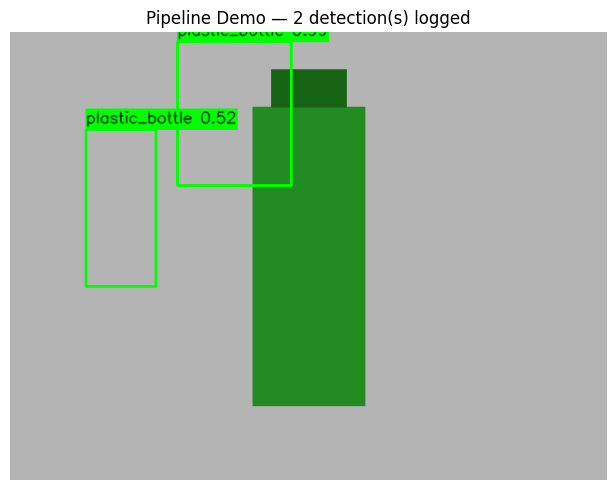

In [18]:
import time

# Synthesise a realistic-looking frame
frame = np.full((480, 640, 3), 180, dtype=np.uint8)   # grey conveyor belt
cv2.rectangle(frame, (260, 80), (380, 400), (34,139,34), -1)   # bottle body
cv2.rectangle(frame, (280, 40), (360, 80),  (20,100,20), -1)   # bottle cap

# Run pipeline
t0         = time.time()
processed  = preprocess_frame(frame)
detections = det.detect(processed)
resp_ms    = (time.time() - t0) * 1000

event_ids = []
for d in detections:
    ctrl.trigger()
    eid = db.log_event(
        frame_number=1,
        confidence_score=d['confidence'],
        bbox_x=int(d['x1']), bbox_y=int(d['y1']),
        bbox_w=int(d['x2']-d['x1']), bbox_h=int(d['y2']-d['y1']),
        response_time_ms=round(resp_ms, 2)
    )
    event_ids.append(eid)

print(f'Detections : {len(detections)}')
print(f'Event IDs  : {event_ids}')
print(f'Response   : {resp_ms:.1f} ms')

# Annotate and show
annotated = draw_bounding_boxes(frame, detections)
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f'Pipeline Demo — {len(detections)} detection(s) logged', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'pipeline_demo.png', dpi=100)
plt.show()

In [21]:
# Show database stats
!pip install pandas
import pandas as pd

stats  = db.get_stats()
events = db.get_recent_events(limit=10)

print('── Database Stats ────────────────────────')
for k, v in stats.items():
    print(f'  {k:<22}: {v}')

print('\n── Recent Events ─────────────────────────')
if events:
    df = pd.DataFrame(events)
    display(df[['event_id','frame_number','confidence_score','bbox_x','bbox_y','bbox_width','bbox_height','timestamp']])
else:
    print('  No events recorded yet.')

ctrl.cleanup()

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------

,event_id,frame_number,confidence_score,bbox_x,bbox_y,bbox_width,bbox_height,timestamp
0,2,1,0.523,81,104,75,168,2026-06-09T11:00:17.092468
1,1,1,0.989,179,10,122,154,2026-06-09T11:00:17.042695


---
## ✅ Notebook 2 Complete

**What was done:**
- Wrote `detector.py`, `controller.py`, `database.py` to disk
- Ran a full detection → arm trigger → database log cycle
- Confirmed event IDs are returned and stats are queryable

**Next:** Open `03_training.ipynb` to train the YOLO model on your dataset.